In [ ]:
# 将 Google Drive 挂载到 Colab 虚拟机，使云端硬盘像本地目录一样可用
from google.colab import drive
drive.mount('/content/drive')

# 代办: 请填写你在 Google Drive 中存放解压后作业文件夹的路径
# 示例：'cs231n/assignments/assignment1/'
# 请根据你的实际路径进行修改
FOLDERNAME = 'cs231n/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] 请填写正确的文件夹路径。"

# 挂载完成后，把该路径加入 Python 的模块搜索路径，
# 确保 Colab 虚拟机的解释器能找到并加载其中的 .py 文件
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# 如果 CIFAR-10 数据集尚未存在，则将其下载到 Google Drive
# 进入数据集目录
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
# 执行下载脚本，自动下载并解压 CIFAR-10
!bash get_datasets.sh
# 下载完成后返回作业根目录
%cd /content/drive/My\ Drive/$FOLDERNAME

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/cs231n/assignments/assignment1/cs231n/datasets
/content/drive/My Drive/cs231n/assignments/assignment1


# 多层全连接网络  
在本练习中，你将实现一个可以包含任意数量隐藏层的全连接神经网络。

In [ ]:
# 这两行代码用于在 Google Colab 中挂载 Google Drive。
# 取消注释后即可将云端硬盘挂载到 /content/drive，方便读写文件。

# from google.colab import drive
# drive.mount('/content/drive')

阅读文件 `cs231n/classifiers/fc_net.py` 中的 `FullyConnectedNet` 类。  

实现网络的初始化、前向传播和反向传播。  
在整个作业过程中，你将在 `cs231n/layers.py` 中逐步完成各个层的实现。  
你可以复用之前已经写好的 `affine_forward`、`affine_backward`、`relu_forward`、`relu_backward` 以及 `softmax_loss` 等函数。  
目前暂时不需要实现 dropout 或 batch/layer normalization，稍后会要求你添加这些功能。


In [ ]:
# ========== 初始化设置单元 ==========
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 从 cs231n 导入将要测试 / 训练的多层全连接网络及相关工具
from cs231n.classifiers.fc_net import *
from cs231n.data_utils import get_CIFAR10_data          # 快速加载 CIFAR-10 的辅助函数
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver                        # 通用训练器（封装了训练循环）

# 让 matplotlib 在 notebook 内嵌显示图形
%matplotlib inline

# 统一设置图片大小、插值方式和灰度图配色，方便观察
plt.rcParams["figure.figsize"] = (10.0, 8.0)
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

# 自动选择可用中文字体，避免图中中文显示为方块
candidate_fonts = [
    "Microsoft YaHei", "SimHei", "SimSun", "KaiTi",
    "Noto Sans CJK SC", "WenQuanYi Zen Hei", "Source Han Sans CN",
    "Arial Unicode MS"
]
installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
available_fonts = [f for f in candidate_fonts if f in installed_fonts]
if available_fonts:
    plt.rcParams["font.sans-serif"] = available_fonts + ["DejaVu Sans"]
else:
    # 找不到中文字体时至少保证图可绘制，并提示用户安装字体
    plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
    print("[提示] 未检测到常见中文字体，中文可能无法显示。可安装 SimHei 或 Noto Sans CJK。")

# 避免坐标轴负号显示成方块
plt.rcParams["axes.unicode_minus"] = False

# 启用 IPython 的自动重载功能：修改 .py 文件后无需重启 kernel 即可生效
%load_ext autoreload
%autoreload 2

# 计算两个矩阵/向量之间的相对误差，常用于数值梯度校验
def rel_error(x, y):
    """返回相对误差。"""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [ ]:
# 加载已经预处理过的 CIFAR-10 数据集
data = get_CIFAR10_data()

# 打印各数据子集的名称与形状
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


## 初始损失与梯度检查

作为完整性检查，请运行以下代码来：

1. 查看网络的初始损失值是否合理；
2. 对网络进行梯度检查，分别测试 **不含正则化** 和 **含正则化** 的情况。

在进行梯度检查时，你应期望得到的相对误差在 **1e-7 或更小**。

In [ ]:
# 设置随机种子，确保结果可复现
np.random.seed(231)
# 构造一个极小批次：2 张图像、每幅 15 维特征、两层隐藏层分别为 20 和 30 个神经元、10 类
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)          # 随机生成输入数据
y = np.random.randint(C, size=(N,))  # 随机生成类别标签

# 分别测试无正则化和有正则化两种情况
for reg in [0, 3.14]:
    print("正在测试，reg =", reg)

    # 构建两层隐藏层的全连接网络
    model = FullyConnectedNet(
        [H1, H2],
        input_dim=D,
        num_classes=C,
        reg=reg,
        weight_scale=5e-2,
        dtype=np.float64
    )

    # 计算初始损失及梯度
    loss, grads = model.loss(X, y)
    print("初始损失:", loss)

    # 对每一组参数进行数值梯度检查
    # 大部分相对误差应 ≤ 1e-7；当 reg=0 时，W2 的误差允许到 1e-5 左右
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]   # 只返回损失的匿名函数
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print(f"{name} 相对误差: {rel_error(grad_num, grads[name])}")

正在测试，reg = 0
初始损失: 2.300479089768492
W1 相对误差: 1.0252674471656573e-07
W2 相对误差: 2.2120479295080622e-05
W3 相对误差: 4.5623278736665505e-07
b1 相对误差: 4.6600944653202505e-09
b2 相对误差: 2.085654276112763e-09
b3 相对误差: 1.689724888469736e-10
正在测试，reg = 3.14
初始损失: 7.052114776533016
W1 相对误差: 3.904541941902138e-09
W2 相对误差: 6.86942277940646e-08
W3 相对误差: 3.483989247437803e-08
b1 相对误差: 1.4752427965311745e-08
b2 相对误差: 1.4615869332918208e-09
b3 相对误差: 1.3200479211447775e-10


作为另一项完整性检查，请确保你的网络可以在 **仅含 50 张图像的小数据集上实现过拟合**。  
我们将先采用一个三层网络，每个隐藏层 100 个神经元。  

在接下来的代码单元中，请调整 **学习率 (learning rate)** 和 **权重初始化尺度 (weight initialization scale)**，  
使得模型在 **20 个 epoch 以内** 达到 **100% 的训练准确率**。

(Iteration 1 / 40) loss: 2.294868
(Epoch 0 / 20) train acc: 0.340000; val_acc: 0.146000
(Epoch 1 / 20) train acc: 0.400000; val_acc: 0.144000
(Epoch 2 / 20) train acc: 0.400000; val_acc: 0.120000
(Epoch 3 / 20) train acc: 0.620000; val_acc: 0.177000
(Epoch 4 / 20) train acc: 0.620000; val_acc: 0.153000
(Epoch 5 / 20) train acc: 0.760000; val_acc: 0.185000
(Iteration 11 / 40) loss: 0.939504
(Epoch 6 / 20) train acc: 0.840000; val_acc: 0.186000
(Epoch 7 / 20) train acc: 0.860000; val_acc: 0.182000
(Epoch 8 / 20) train acc: 0.760000; val_acc: 0.188000
(Epoch 9 / 20) train acc: 0.760000; val_acc: 0.182000
(Epoch 10 / 20) train acc: 0.980000; val_acc: 0.201000
(Iteration 21 / 40) loss: 0.204861
(Epoch 11 / 20) train acc: 0.980000; val_acc: 0.198000
(Epoch 12 / 20) train acc: 0.980000; val_acc: 0.194000
(Epoch 13 / 20) train acc: 0.980000; val_acc: 0.180000
(Epoch 14 / 20) train acc: 0.960000; val_acc: 0.191000
(Epoch 15 / 20) train acc: 0.980000; val_acc: 0.172000
(Iteration 31 / 40) loss: 

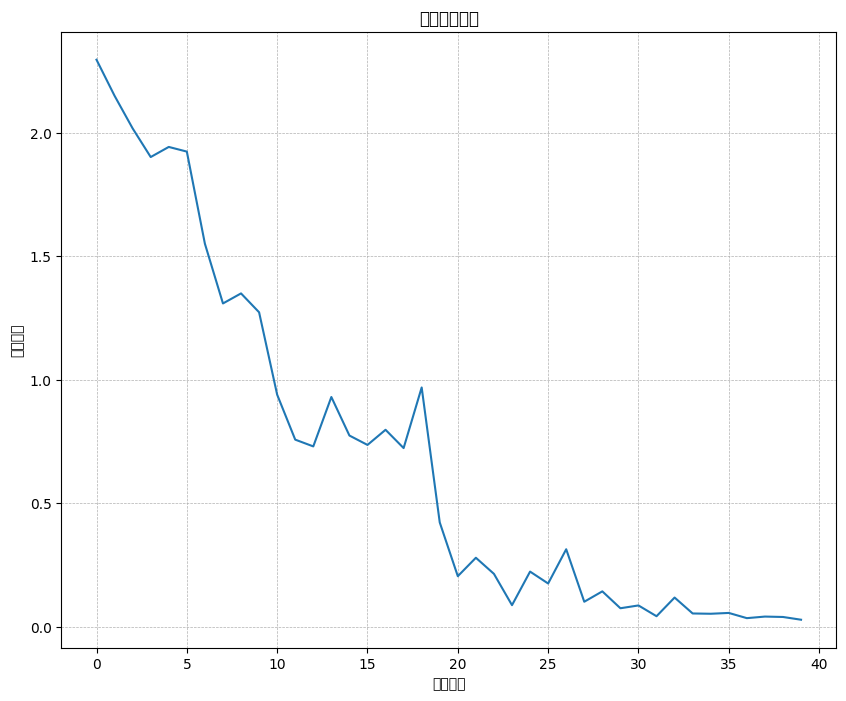

In [ ]:
# TODO：仅用三层网络（每层 100 个神经元）在 50 个训练样本上过拟合，
# 只需调节学习率和权重初始化尺度即可。
num_train = 50  # 仅取前 50 张图片作为极小训练集
small_data = {
    "X_train": data["X_train"][:num_train],
    "y_train": data["y_train"][:num_train],
    "X_val":   data["X_val"],
    "y_val":   data["y_val"],
}

# 以下两个超参数需要你手动尝试不同数值，以达到 20 个 epoch 内 100% 训练准确率
weight_scale = 1e-2   # 权重初始化标准差，可调
learning_rate = 1e-2  # SGD 学习率，可调

# 构造三层网络（两个 100 神经元隐藏层）
model = FullyConnectedNet(
    [100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)

# 创建通用训练器 Solver
solver = Solver(
    model,
    small_data,
    print_every=10,                # 每 10 次迭代打印一次
    num_epochs=20,                 # 总共训练 20 个 epoch
    batch_size=25,                 # 每个 mini-batch 25 张图
    update_rule="sgd",             # 使用普通 SGD
    optim_config={"learning_rate": learning_rate},
)

solver.train()  # 开始训练

# 绘制训练损失曲线，观察是否迅速降到接近 0，验证过拟合
plt.plot(solver.loss_history)
plt.title("训练损失历史")
plt.xlabel("迭代次数")
plt.ylabel("训练损失")
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

接下来，请尝试使用一个 **五层网络**，每层 100 个神经元，在 50 张训练样本上实现过拟合。  
你依旧需要手动调整 **学习率** 和 **权重初始化尺度**，  
但同样应当在 **20 个 epoch 内** 达到 **100% 的训练准确率**。

(Iteration 1 / 40) loss: 2.805975
(Epoch 0 / 20) train acc: 0.140000; val_acc: 0.084000
(Epoch 1 / 20) train acc: 0.180000; val_acc: 0.114000
(Epoch 2 / 20) train acc: 0.620000; val_acc: 0.123000
(Epoch 3 / 20) train acc: 0.700000; val_acc: 0.126000
(Epoch 4 / 20) train acc: 0.800000; val_acc: 0.132000
(Epoch 5 / 20) train acc: 0.820000; val_acc: 0.146000
(Iteration 11 / 40) loss: 0.982811
(Epoch 6 / 20) train acc: 0.840000; val_acc: 0.134000
(Epoch 7 / 20) train acc: 0.880000; val_acc: 0.144000
(Epoch 8 / 20) train acc: 0.900000; val_acc: 0.140000
(Epoch 9 / 20) train acc: 0.940000; val_acc: 0.134000
(Epoch 10 / 20) train acc: 0.980000; val_acc: 0.147000
(Iteration 21 / 40) loss: 0.076448
(Epoch 11 / 20) train acc: 0.920000; val_acc: 0.177000
(Epoch 12 / 20) train acc: 0.940000; val_acc: 0.163000
(Epoch 13 / 20) train acc: 1.000000; val_acc: 0.162000
(Epoch 14 / 20) train acc: 1.000000; val_acc: 0.149000
(Epoch 15 / 20) train acc: 1.000000; val_acc: 0.148000
(Iteration 31 / 40) loss: 

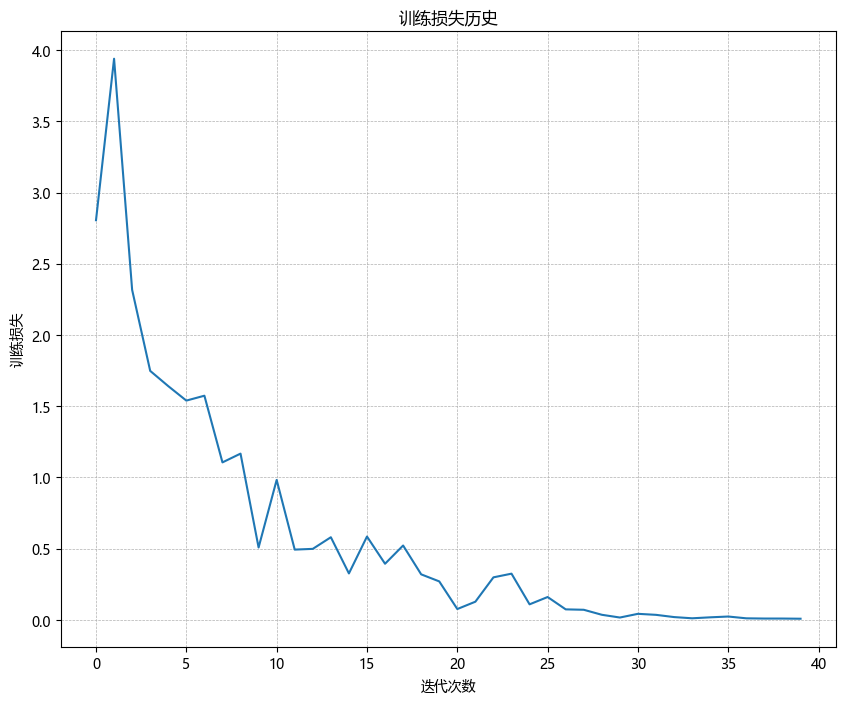

In [ ]:
# TODO：仅用五层网络（每层 100 个神经元）在 50 个训练样本上过拟合，
# 只需调节学习率和权重初始化尺度即可。

np.random.seed(231)  # 固定随机种子，便于复现调参结果
num_train = 50  # 仅取前 50 张图片作为极小训练集
small_data = {
    'X_train': data['X_train'][:num_train],
    'y_train': data['y_train'][:num_train],
    'X_val':   data['X_val'],
    'y_val':   data['y_val'],
}

# 这一组在当前实现上可在 20 个 epoch 内达到 100% 训练准确率
learning_rate = 3e-2  # 学习率，可继续微调
weight_scale  = 4e-2  # 权重初始化标准差，可继续微调

# 构造五层网络（四个 100 神经元隐藏层）
model = FullyConnectedNet(
    [100, 100, 100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)

# 创建通用训练器 Solver
solver = Solver(
    model,
    small_data,
    print_every=10,               # 每 10 次迭代打印一次
    num_epochs=20,                # 总共训练 20 个 epoch
    batch_size=25,                # 每个 mini-batch 25 张图
    update_rule='sgd',            # 使用普通 SGD
    optim_config={'learning_rate': learning_rate},
)

solver.train()  # 开始训练

# 绘制训练损失曲线，观察是否迅速降到接近 0，验证过拟合
plt.plot(solver.loss_history)
plt.title('训练损失历史')
plt.xlabel('迭代次数')
plt.ylabel('训练损失')
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

## 内联问题 1：
在训练三层网络和五层网络时，你有没有发现什么差异？  
特别是，根据你的实际操作，哪一个网络对**初始化尺度**更敏感？你觉得为什么会这样？

## 答案：
三层网络超参数两下就调好，这几把的五层网络我调了半天都卡在0.16，也就是纯猜的水平
因为每一层都要乘那个超参，所以就会导致很小的差距就会有很大的准确率差别




# 参数更新规则（Update Rules）

迄今为止，我们一直使用最普通的随机梯度下降（vanilla SGD）作为参数更新规则。  
更先进的更新规则能够显著降低深度网络的训练难度。  
接下来我们将实现几种最常用的更新规则，并将它们与 vanilla SGD 进行对比。

## SGD + Momentum
带动量的随机梯度下降（SGD+Momentum）是一种广泛使用的参数更新规则，相比最原始的随机梯度下降，它通常能让深度网络收敛得更快。  
更多细节可参考 Momentum Update 章节：http://cs231n.github.io/neural-networks-3/#sgd

打开文件 `cs231n/optim.py`，先阅读文件顶部的 API 文档，确保你理解接口要求。  
然后在 `sgd_momentum` 函数中实现 **SGD+Momentum** 更新规则，并运行下方代码检查实现是否正确。  
检查时应看到所有相对误差小于 1e-8。

In [ ]:
# 从 cs231n.optim 中导入 sgd_momentum 函数，用于测试你的实现
from cs231n.optim import sgd_momentum

# 构造测试数据：权重 w、梯度 dw、动量 v
N, D = 4, 5
w  = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
v  = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

# 配置字典：学习率 + 当前动量
config = {"learning_rate": 1e-3, "velocity": v}

# 调用你实现的 sgd_momentum，得到下一次权重 next_w 与更新后的动量
next_w, _ = sgd_momentum(w, dw, config=config)

# 期望的正确结果（由官方给出的参考实现计算）
expected_next_w = np.asarray([
    [0.1406,      0.20738947,  0.27417895,  0.34096842,  0.40775789],
    [0.47454737,  0.54133684,  0.60812632,  0.67491579,  0.74170526],
    [0.80849474,  0.87528421,  0.94207368,  1.00886316,  1.07565263],
    [1.14244211,  1.20923158,  1.27602105,  1.34281053,  1.4096    ]])
expected_velocity = np.asarray([
    [0.5406,      0.55475789,  0.56891579, 0.58307368,  0.59723158],
    [0.61138947,  0.62554737,  0.63970526,  0.65386316,  0.66802105],
    [0.68217895,  0.69633684,  0.71049474,  0.72465263,  0.73881053],
    [0.75296842,  0.76712632,  0.78128421,  0.79544211,  0.8096    ]])

# 计算并打印相对误差，应接近 1e-8 或更小
print("next_w 相对误差: ", rel_error(next_w, expected_next_w))
print("velocity 相对误差: ", rel_error(expected_velocity, config["velocity"]))

next_w 相对误差:  8.882347033505819e-09
velocity 相对误差:  4.269287743278663e-09


完成上述步骤后，运行下面的代码，用 **普通 SGD** 和 **SGD + Momentum** 分别训练一个六层网络。  
你应该能看到采用 **SGD + Momentum** 更新规则时，网络收敛得更快。

Running with  sgd
(Iteration 1 / 200) loss: 2.534428
(Epoch 0 / 5) train acc: 0.083000; val_acc: 0.095000
(Iteration 11 / 200) loss: 2.272551
(Iteration 21 / 200) loss: 2.099137
(Iteration 31 / 200) loss: 2.174980
(Epoch 1 / 5) train acc: 0.249000; val_acc: 0.233000
(Iteration 41 / 200) loss: 2.063420
(Iteration 51 / 200) loss: 2.092000
(Iteration 61 / 200) loss: 2.026439
(Iteration 71 / 200) loss: 2.004612
(Epoch 2 / 5) train acc: 0.311000; val_acc: 0.261000
(Iteration 81 / 200) loss: 1.983295
(Iteration 91 / 200) loss: 1.969099
(Iteration 101 / 200) loss: 1.964826
(Iteration 111 / 200) loss: 2.013370
(Epoch 3 / 5) train acc: 0.328000; val_acc: 0.286000
(Iteration 121 / 200) loss: 1.795546
(Iteration 131 / 200) loss: 1.923325
(Iteration 141 / 200) loss: 1.818393
(Iteration 151 / 200) loss: 1.838703
(Epoch 4 / 5) train acc: 0.353000; val_acc: 0.302000
(Iteration 161 / 200) loss: 1.783294
(Iteration 171 / 200) loss: 1.763784
(Iteration 181 / 200) loss: 1.757954
(Iteration 191 / 200) los

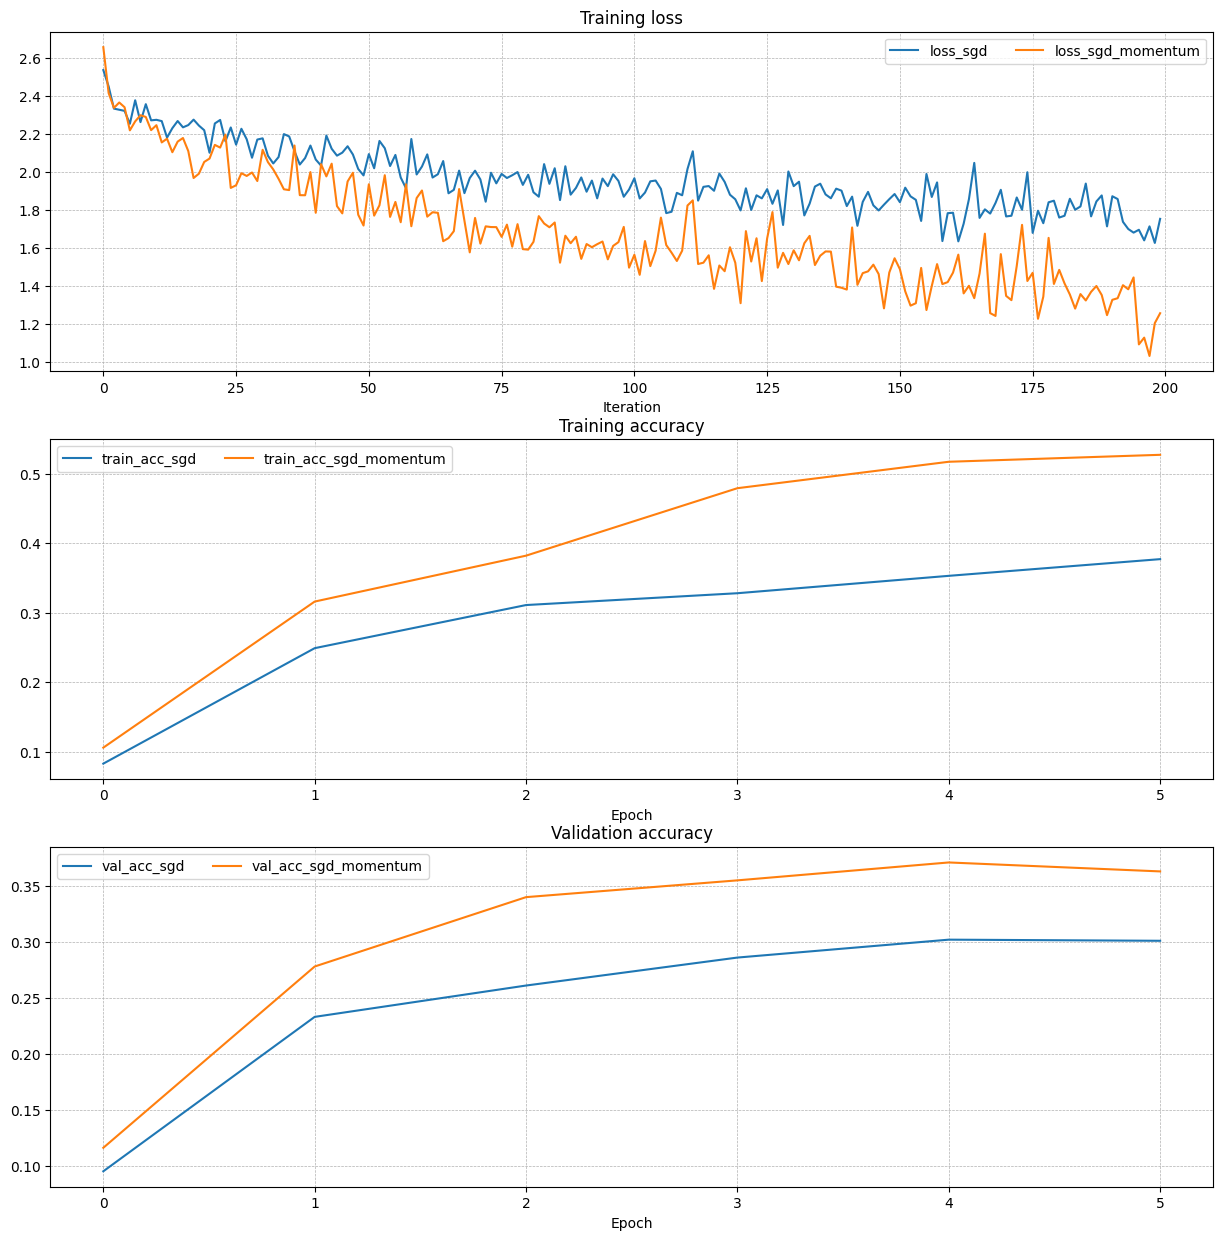

In [ ]:
num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}

for update_rule in ['sgd', 'sgd_momentum']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )

    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': 5e-3},
        verbose=True,
    )
    solvers[update_rule] = solver
    solver.train()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"loss_{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"train_acc_{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"val_acc_{update_rule}")

for ax in axes:
    ax.legend(loc="best", ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## RMSProp 与 Adam  
RMSProp [1] 和 Adam [2] 是两种更新规则，它们通过维护梯度的**二阶矩**（即平方梯度）的滑动平均，来为每个参数单独设置学习率。

请在文件 `cs231n/optim.py` 中完成以下实现：  
- 在 `rmsprop` 函数里实现 **RMSProp** 更新规则；  
- 在 `adam` 函数里实现 **Adam** 更新规则。  

**注意：** 请实现**完整的 Adam** 更新规则（包含偏差修正机制），而不是课程笔记中最初提到的简化版本。

[1] Tijmen Tieleman 和 Geoffrey Hinton. “Lecture 6.5-RMSProp: Divide the gradient by a running average of its recent magnitude.” COURSERA: Neural Networks for Machine Learning 4 (2012).  
[2] Diederik Kingma 和 Jimmy Ba, “Adam: A Method for Stochastic Optimization”, ICLR 2015.

In [ ]:
# 测试 RMSProp 实现
from cs231n.optim import rmsprop

# 构造测试数据
N, D = 4, 5
w     = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)   # 当前权重
dw    = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)   # 当前梯度
cache = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)    # 缓存的平方梯度滑动平均

# 配置字典：学习率 + 当前 cache
config = {'learning_rate': 1e-2, 'cache': cache}
next_w, _ = rmsprop(w, dw, config=config)

# 官方给出的期望结果
expected_next_w = np.asarray([
  [-0.39223849, -0.34037513, -0.28849239, -0.23659121, -0.18467247],
  [-0.132737,   -0.08078555, -0.02881884,  0.02316247,  0.07515774],
  [ 0.12716641,  0.17918792,  0.23122175,  0.28326742,  0.33532447],
  [ 0.38739248,  0.43947102,  0.49155973,  0.54365823,  0.59576619]])
expected_cache = np.asarray([
  [ 0.5976,      0.6126277,   0.6277108,   0.64284931,  0.65804321],
  [ 0.67329252,  0.68859723,  0.70395734,  0.71937285,  0.73484377],
  [ 0.75037008,  0.7659518,   0.78158892,  0.79728144,  0.81302936],
  [ 0.82883269,  0.84469141,  0.86060554,  0.87657507,  0.8926    ]])

# 计算并打印相对误差，应接近 1e-7 或更小
print('next_w 误差: ', rel_error(expected_next_w, next_w))
print('cache 误差: ', rel_error(expected_cache, config['cache']))

next_w 误差:  9.524687511038133e-08
cache 误差:  2.6477955807156126e-09


In [ ]:
# 测试 Adam 实现
from cs231n.optim import adam

# 构造测试数据
N, D = 4, 5
w  = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)   # 当前权重
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)   # 当前梯度
m  = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)    # 一阶动量（梯度均值）
v  = np.linspace(0.7, 0.5, num=N*D).reshape(N, D)    # 二阶动量（梯度平方均值）

# 配置字典：学习率 + 当前一阶/二阶动量 + 迭代计数 t
config = {'learning_rate': 1e-2, 'm': m, 'v': v, 't': 5}
next_w, _ = adam(w, dw, config=config)

# 官方给出的期望结果（含完整的偏差修正）
expected_next_w = np.asarray([
    [-0.40094747, -0.34836187, -0.29577703, -0.24319299, -0.19060977],
    [-0.1380274,  -0.08544591, -0.03286534,  0.01971428,  0.0722929],
    [ 0.1248705,   0.17744702,  0.23002243,  0.28259667,  0.33516969],
    [ 0.38774145,  0.44031188,  0.49288093,  0.54544852,  0.59801459]])
expected_v = np.asarray([
    [0.69966,     0.68908382,  0.67851319,  0.66794809,  0.65738853],
    [0.64683452,  0.63628604,  0.6257431,   0.61520571,  0.60467385],
    [0.59414753,  0.58362676,  0.57311152,  0.56260183,  0.55209767],
    [0.54159906,  0.53110598,  0.52061845,  0.51013645,  0.49966   ]])
expected_m = np.asarray([
    [0.48,        0.49947368,  0.51894737,  0.53842105,  0.55789474],
    [0.57736842,  0.59684211,  0.61631579,  0.63578947,  0.65526316],
    [0.67473684,  0.69421053,  0.71368421,  0.73315789,  0.75263158],
    [0.77210526,  0.79157895,  0.81105263,  0.83052632,  0.85      ]])

# 计算并打印相对误差，应接近 1e-7 或更小
print('next_w 误差: ', rel_error(expected_next_w, next_w))
print('v 误差: ', rel_error(expected_v, config['v']))
print('m 误差: ', rel_error(expected_m, config['m']))

next_w 误差:  1.1395691798535431e-07
v 误差:  4.208314038113071e-09
m 误差:  4.214963193114416e-09


当你已经调试好 RMSProp 和 Adam 的实现后，请运行下面的代码，用这两种新的更新规则分别训练一组深层网络。

开始运行： adam
(Iteration 1 / 200) loss: 2.481510
(Epoch 0 / 5) train acc: 0.111000; val_acc: 0.114000
(Iteration 11 / 200) loss: 2.108005
(Iteration 21 / 200) loss: 2.056319
(Iteration 31 / 200) loss: 1.890514
(Epoch 1 / 5) train acc: 0.329000; val_acc: 0.312000
(Iteration 41 / 200) loss: 1.926332
(Iteration 51 / 200) loss: 1.583571
(Iteration 61 / 200) loss: 1.650018
(Iteration 71 / 200) loss: 1.611574
(Epoch 2 / 5) train acc: 0.433000; val_acc: 0.329000
(Iteration 81 / 200) loss: 1.773834
(Iteration 91 / 200) loss: 1.543570
(Iteration 101 / 200) loss: 1.362303
(Iteration 111 / 200) loss: 1.649464
(Epoch 3 / 5) train acc: 0.476000; val_acc: 0.343000
(Iteration 121 / 200) loss: 1.590956
(Iteration 131 / 200) loss: 1.621823
(Iteration 141 / 200) loss: 1.272050
(Iteration 151 / 200) loss: 1.409405
(Epoch 4 / 5) train acc: 0.504000; val_acc: 0.351000
(Iteration 161 / 200) loss: 1.532882
(Iteration 171 / 200) loss: 1.172978
(Iteration 181 / 200) loss: 1.153096
(Iteration 191 / 200) loss: 1.45

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  fig.canvas

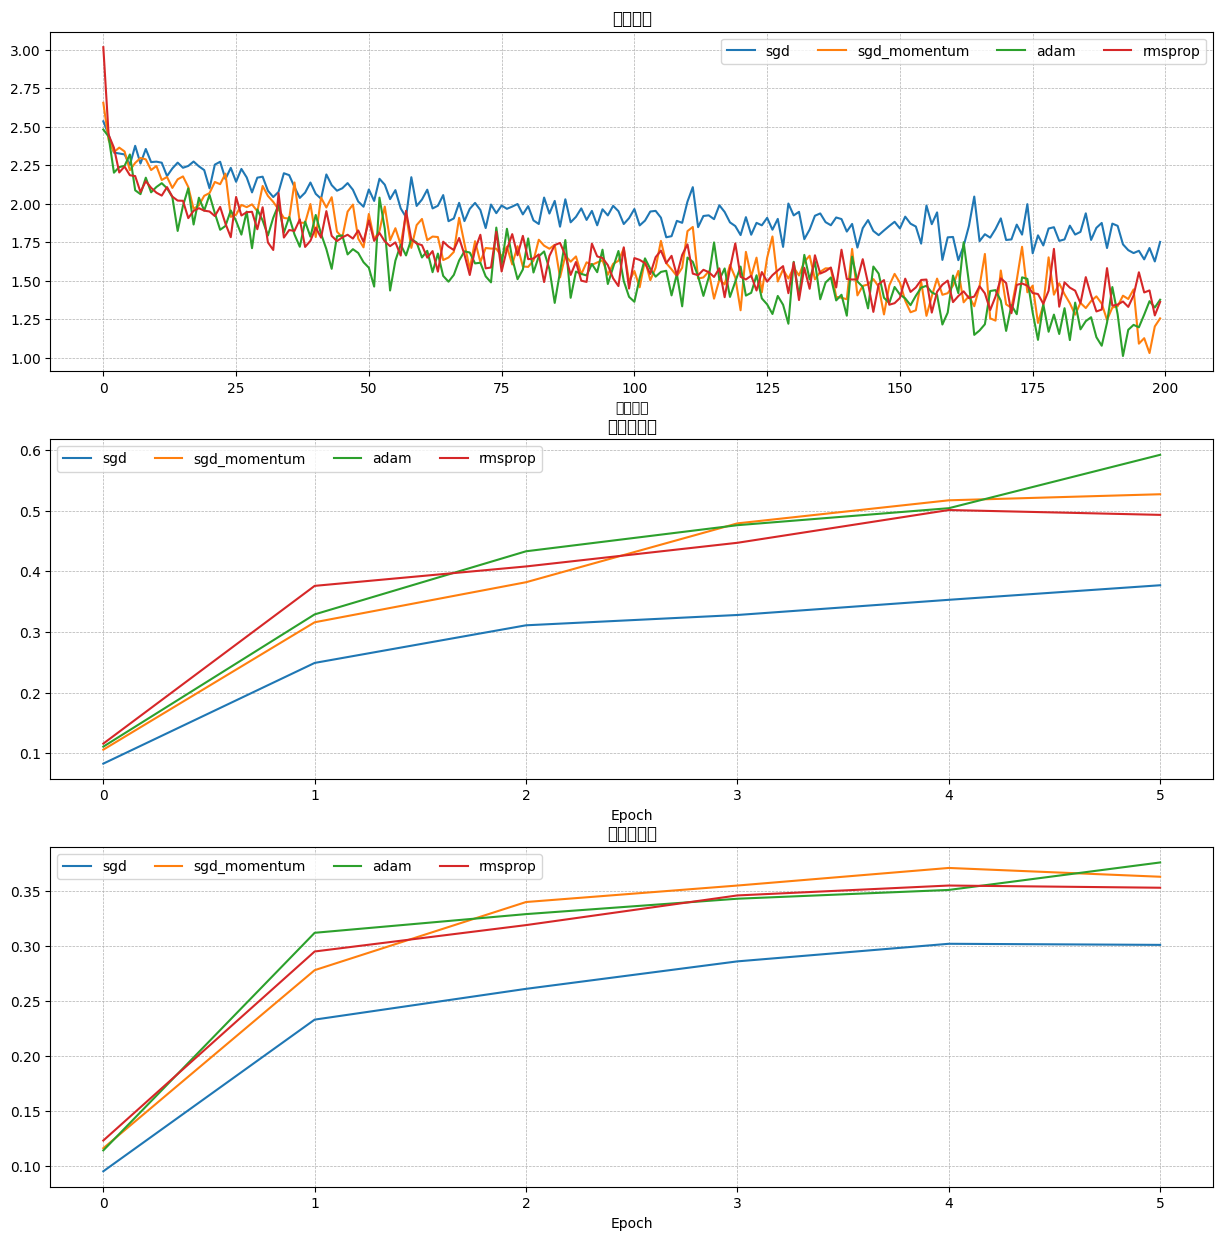

In [ ]:
# 为 RMSProp 与 Adam 分别设置不同的学习率
learning_rates = {'rmsprop': 1e-4, 'adam': 1e-3}

# 依次用 'adam' 和 'rmsprop' 两种更新规则训练网络
for update_rule in ['adam', 'rmsprop']:
    print('开始运行：', update_rule)

    # 构建五层全连接网络（每层 100 个神经元）
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )

    # 使用通用训练器 Solver
    solver = Solver(
        model,
        small_data,
        num_epochs=5,                              # 训练 5 个 epoch
        batch_size=100,                            # 每个 mini-batch 100 张图
        update_rule=update_rule,                   # 指定优化器
        optim_config={'learning_rate': learning_rates[update_rule]},  # 对应学习率
        verbose=True                               # 打印训练日志
    )
    solvers[update_rule] = solver
    solver.train()                               # 开始训练
    print()                                      # 空行方便阅读

# 绘制训练过程中的损失、训练准确率、验证准确率曲线
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('训练损失')
axes[0].set_xlabel('迭代次数')

axes[1].set_title('训练准确率')
axes[1].set_xlabel('Epoch')

axes[2].set_title('验证准确率')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history,      label=f"{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"{update_rule}")
    axes[2].plot(solver.val_acc_history,   label=f"{update_rule}")

for ax in axes:
    ax.legend(loc='best', ncol=4)           # 图例
    ax.grid(linestyle='--', linewidth=0.5)  # 网格线便于观察趋势

plt.show()

## 内联问题 2：

AdaGrad 与 Adam 类似，是一种**逐参数**的优化方法，其更新规则如下：

```
cache += dw**2
w += - learning_rate * dw / (np.sqrt(cache) + eps)
```

John 发现，当使用 AdaGrad 训练网络时，更新量变得越来越小，网络学习速度变慢。  
请结合 AdaGrad 的更新规则，解释为什么会出现这种现象？Adam 是否也会遇到同样的问题？

## 答案：
在 AdaGrad 的更新规则中，cache 是历史梯度平方的累加和。由于平方项始终为正，cache 会随着训练过程单调递增。由于 cache 处于学习率更新公式的分母位置，这会导致有效学习率不断减小，最终变得微乎其微，使网络停止学习。
Adam 不会遇到同样的问题。因为 Adam 使用了指数移动平均（Exponential Moving Average）来更新 cache（二阶动量），它通过衰减因子赋予了历史梯度较小的权重。这使得 cache 能够反映近期梯度的规模，而不是盲目累加，从而避免了有效学习率过早归零的问题。




# 训练一个优秀的模型！  
请你在 CIFAR-10 上训练一个性能最好的全连接网络，并将最优模型保存到变量 `best_model` 中。  
我们要求你的模型在验证集上至少达到 **50% 的准确率**。

如果你认真调参，完全有可能把验证准确率提高到 **55% 以上**，但这部分不做强制要求，也不会额外加分。  
在下一项作业中，我们会要求你训练一个性能最好的卷积神经网络；因此我们更希望你把主要精力放在卷积网络上，而非全连接网络。

**提示：** 在下一项作业里，你将学到 **批归一化（BatchNormalization）** 和 **Dropout** 等技术，它们能帮助你训练更强大的模型。

(Iteration 1 / 4900) loss: 4.433891
(Epoch 0 / 20) train acc: 0.157000; val_acc: 0.148000
(Iteration 101 / 4900) loss: 2.474880
(Iteration 201 / 4900) loss: 2.321512
(Epoch 1 / 20) train acc: 0.468000; val_acc: 0.439000
(Iteration 301 / 4900) loss: 2.142711
(Iteration 401 / 4900) loss: 1.983899
(Epoch 2 / 20) train acc: 0.494000; val_acc: 0.465000
(Iteration 501 / 4900) loss: 1.873336
(Iteration 601 / 4900) loss: 1.926852
(Iteration 701 / 4900) loss: 1.756241
(Epoch 3 / 20) train acc: 0.508000; val_acc: 0.488000
(Iteration 801 / 4900) loss: 1.738873
(Iteration 901 / 4900) loss: 1.681189
(Epoch 4 / 20) train acc: 0.529000; val_acc: 0.497000
(Iteration 1001 / 4900) loss: 1.714500
(Iteration 1101 / 4900) loss: 1.574467
(Iteration 1201 / 4900) loss: 1.503318
(Epoch 5 / 20) train acc: 0.552000; val_acc: 0.484000
(Iteration 1301 / 4900) loss: 1.494528
(Iteration 1401 / 4900) loss: 1.563805
(Epoch 6 / 20) train acc: 0.557000; val_acc: 0.506000
(Iteration 1501 / 4900) loss: 1.414448
(Iteration

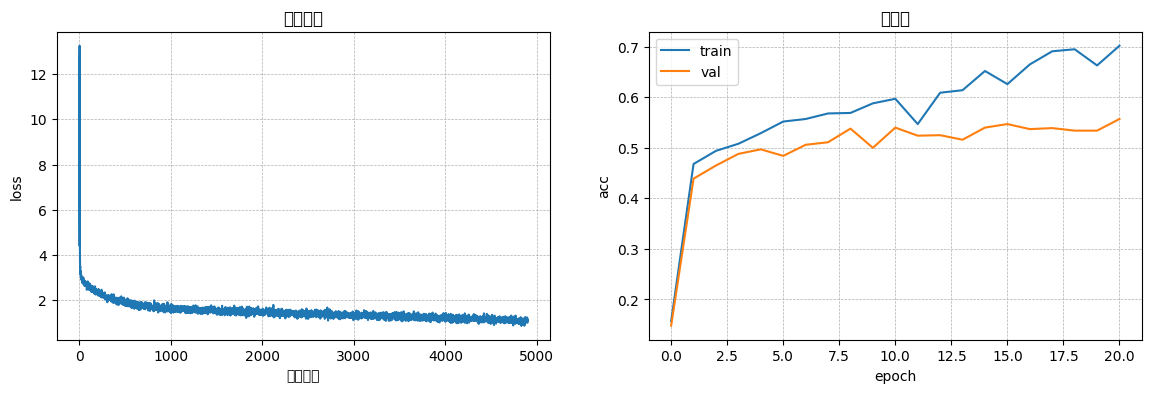

In [48]:
best_model = None

################################################################################
# 代办：在 CIFAR-10 上训练你能得到的最佳 FullyConnectedNet。你可以尝试使用      #
# 批归一化（batch normalization）、层归一化（layer normalization）或 Dropout。  #
# 请将表现最好的模型保存到变量 best_model 中。                                  #
################################################################################
# *****你的代码开始（请勿删除或修改此行）*****

np.random.seed(231)
model = FullyConnectedNet(
    [600, 500, 400],
    input_dim=3 * 32 * 32,
    num_classes=10,
    normalization="batchnorm",
    dropout_keep_ratio=0.75,
    reg=2e-3,
    weight_scale=2e-2,
    dtype=np.float32,
)

solver = Solver(
    model,
    data,
    update_rule="adam",
    optim_config={"learning_rate": 1e-3},
    lr_decay=0.95,
    num_epochs=20,
    batch_size=200,
    print_every=100,
    num_train_samples=1000,
    num_val_samples=None,
    verbose=True,
)

solver.train()
best_model = model

print("最佳验证集准确率:", np.max(solver.val_acc_history))

plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.plot(solver.loss_history)
plt.title("训练损失")
plt.xlabel("迭代次数")
plt.ylabel("loss")
plt.grid(linestyle="--", linewidth=0.5)

plt.subplot(1, 2, 2)
plt.plot(solver.train_acc_history, label="train")
plt.plot(solver.val_acc_history, label="val")
plt.title("准确率")
plt.xlabel("epoch")
plt.ylabel("acc")
plt.legend(loc="best")
plt.grid(linestyle="--", linewidth=0.5)
plt.show()

# *****你的代码结束（请勿删除或修改此行）*****
################################################################################
#                              代码结束                                        #
################################################################################

# 测试你的模型！  
用你训练出的最优模型在验证集和测试集上运行。  
你应当在**验证集**和**测试集**上都至少达到 **50% 的准确率**。

In [49]:
# 使用最优模型在测试集和验证集上预测类别
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)  # 测试集预测
y_val_pred  = np.argmax(best_model.loss(data['X_val']), axis=1)   # 验证集预测

# 计算并打印准确率
print('验证集准确率: ', (y_val_pred == data['y_val']).mean())
print('测试集准确率: ', (y_test_pred == data['y_test']).mean())

验证集准确率:  0.557
测试集准确率:  0.534
